#Image Enhancement untuk Citra Terdegradasi
Muhammad Ilhamuddin (25/559695/PA/23555)

##Import library

In [ ]:
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
from PIL import Image
import matplotlib.pyplot as plt
import os

##Memuat dan menyimpan citra

In [ ]:
def load_image(path):
    image = Image.open(path).convert("RGB")
    return np.array(image).astype(np.float64)


def save_image(array, path):
    array = np.clip(array, 0, 255).astype(np.uint8)
    Image.fromarray(array).save(path)

##Konversi ruang warna RGB ke YCbCr

In [ ]:
def rgb_to_ycbcr(image):
    r, g, b = image[:, :, 0], image[:, :, 1], image[:, :, 2]
    y = 0.299 * r + 0.587 * g + 0.114 * b
    cb = 128 - 0.168736 * r - 0.331264 * g + 0.5 * b
    cr = 128 + 0.5 * r - 0.418688 * g - 0.081312 * b
    return np.stack([y, cb, cr], axis=2)


def ycbcr_to_rgb(image):
    y, cb, cr = image[:, :, 0], image[:, :, 1], image[:, :, 2]
    r = y + 1.402 * (cr - 128)
    g = y - 0.344136 * (cb - 128) - 0.714136 * (cr - 128)
    b = y + 1.772 * (cb - 128)
    return np.stack([r, g, b], axis=2)

##Histogram equalization untuk citra kontras rendah

In [ ]:
def equalize_channel(channel):
    channel = np.clip(channel, 0, 255).astype(np.uint8)
    histogram = np.bincount(channel.flatten(), minlength=256)
    cdf = np.cumsum(histogram)
    cdf_min = cdf[cdf > 0].min()
    total_pixels = channel.size
    lookup = np.round((cdf - cdf_min) / (total_pixels - cdf_min) * 255)
    lookup = np.clip(lookup, 0, 255)
    return lookup[channel]


def equalize_luminance(image):
    ycbcr = rgb_to_ycbcr(image)
    ycbcr[:, :, 0] = equalize_channel(ycbcr[:, :, 0])
    return ycbcr_to_rgb(ycbcr)

##Koreksi gamma untuk citra underexposure dan overexposure

In [ ]:
def gamma_correction_luminance(image, gamma):
    ycbcr = rgb_to_ycbcr(image)
    normalized = ycbcr[:, :, 0] / 255.0
    corrected = np.power(normalized, gamma) * 255.0
    ycbcr[:, :, 0] = corrected
    return ycbcr_to_rgb(ycbcr)

##Kernel Gaussian dan konvolusi 2D

In [ ]:
def generate_gaussian_kernel(size, sigma):
    half = size // 2
    axis = np.arange(-half, half + 1)
    xx, yy = np.meshgrid(axis, axis)
    kernel = np.exp(-(xx ** 2 + yy ** 2) / (2 * sigma ** 2))
    return kernel / kernel.sum()


def convolve2d(channel, kernel):
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(channel, ((pad_h, pad_h), (pad_w, pad_w)), mode="edge")
    windows = sliding_window_view(padded, (kh, kw))
    flipped = kernel[::-1, ::-1]
    return np.einsum("ijkl,kl->ij", windows, flipped)

##Unsharp masking untuk citra blur

In [ ]:
def unsharp_mask(image, kernel_size, sigma, alpha):
    kernel = generate_gaussian_kernel(kernel_size, sigma)
    result = np.zeros_like(image)
    for c in range(3):
        blurred = convolve2d(image[:, :, c], kernel)
        detail = image[:, :, c] - blurred
        result[:, :, c] = image[:, :, c] + alpha * detail
    return result

##Fungsi bantu untuk menampilkan perbandingan

In [ ]:
def show_comparison(original, enhanced, title_left, title_right):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(np.clip(original, 0, 255).astype(np.uint8))
    axes[0].set_title(title_left)
    axes[0].axis("off")
    axes[1].imshow(np.clip(enhanced, 0, 255).astype(np.uint8))
    axes[1].set_title(title_right)
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()


def show_histogram(original, enhanced, title):
    y_original = rgb_to_ycbcr(original)[:, :, 0]
    y_enhanced = rgb_to_ycbcr(enhanced)[:, :, 0]
    plt.figure(figsize=(8, 4))
    plt.hist(y_original.flatten(), bins=256, range=(0, 255), alpha=0.6, label="Sebelum")
    plt.hist(y_enhanced.flatten(), bins=256, range=(0, 255), alpha=0.6, label="Sesudah")
    plt.title(title)
    plt.xlabel("Intensitas")
    plt.ylabel("Jumlah piksel")
    plt.legend()
    plt.show()

##Memuat keempat citra uji

In [ ]:
low_contrast = load_image("low_contrast.jpg")
underexposure = load_image("underexposure.jpeg")
overexposure = load_image("overexposure.jpeg")
blur = load_image("blur.jpeg")

print("Rata-rata intensitas low_contrast.jpg  :", low_contrast.mean())
print("Rata-rata intensitas underexposure.jpeg:", underexposure.mean())
print("Rata-rata intensitas overexposure.jpeg :", overexposure.mean())
print("Rata-rata intensitas blur.jpeg         :", blur.mean())

Rata-rata intensitas low_contrast.jpg  : 71.66130488888889
Rata-rata intensitas underexposure.jpeg: 9.489614239299643
Rata-rata intensitas overexposure.jpeg : 178.64108590074596
Rata-rata intensitas blur.jpeg         : 149.0795650421627


##Enhancement citra kontras rendah (low_contrast.jpg)

Citra ini merupakan foto suasana malam di sebuah area pertokoan dengan lampu hias, sepeda yang diparkir di pagar besi, kendaraan, dan beberapa orang di sekitarnya. Sebagian besar piksel terkumpul pada rentang intensitas yang sempit sehingga kontrasnya terasa datar dan detail pada bagian yang temaram kurang terlihat. Histogram equalization diterapkan untuk menyebarkan intensitas ke seluruh rentang 0-255.

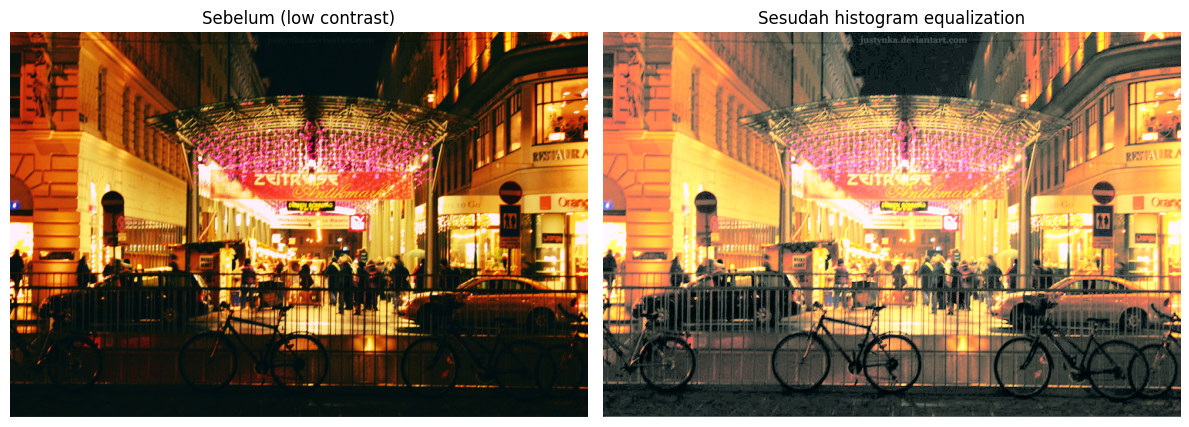

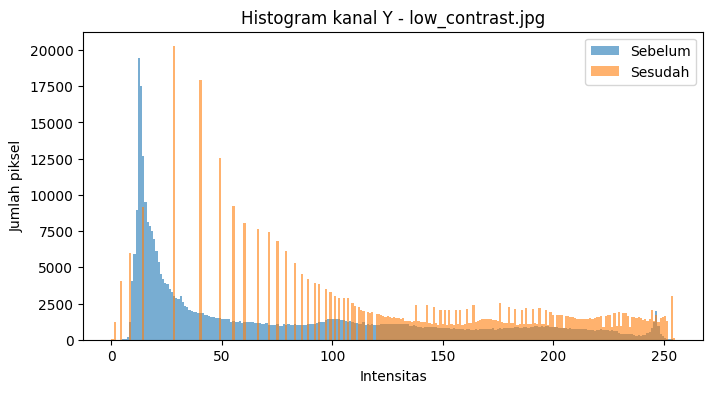

In [ ]:
low_contrast_result = equalize_luminance(low_contrast)
show_comparison(low_contrast, low_contrast_result, "Sebelum (low contrast)", "Sesudah histogram equalization")
show_histogram(low_contrast, low_contrast_result, "Histogram kanal Y - low_contrast.jpg")

##Enhancement citra underexposure (underexposure.jpeg)

Citra altar gereja ini terlalu gelap sehingga detail seperti bunga, salib, dan tulisan pada kain altar hampir tidak terlihat. Koreksi gamma dengan nilai gamma di bawah 1 diterapkan untuk mengangkat intensitas area gelap tanpa membuat area yang sudah terang menjadi over-saturasi.

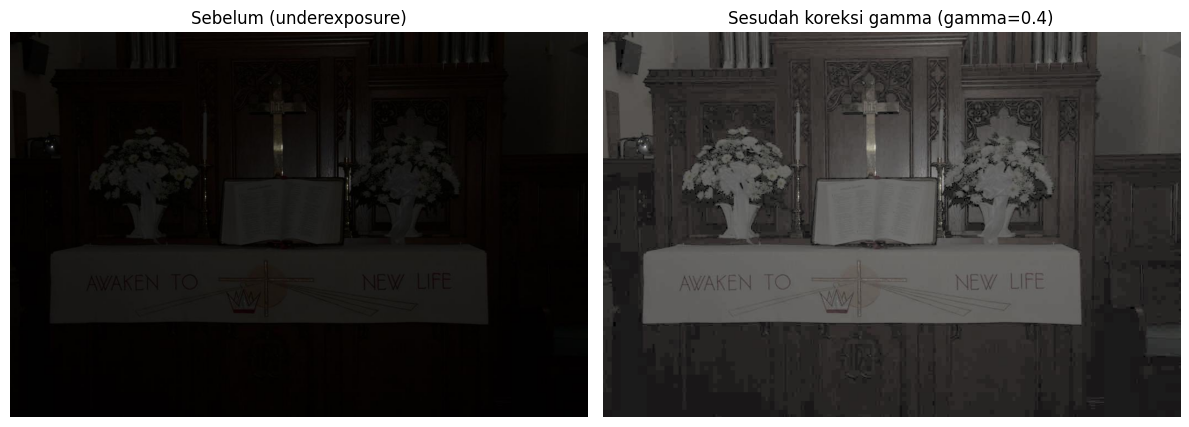

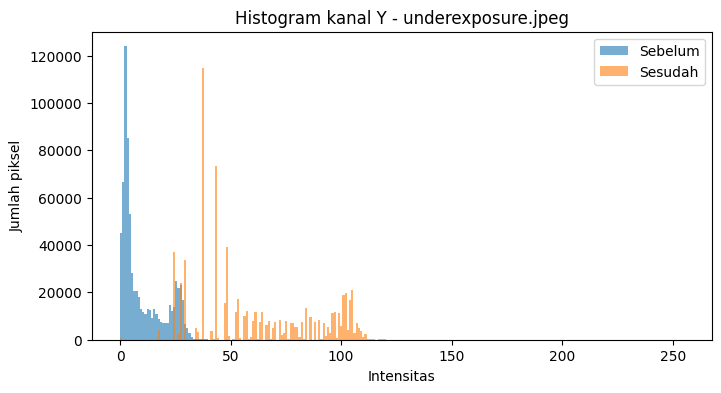

In [ ]:
underexposure_result = gamma_correction_luminance(underexposure, gamma=0.4)
show_comparison(underexposure, underexposure_result, "Sebelum (underexposure)", "Sesudah koreksi gamma (gamma=0.4)")
show_histogram(underexposure, underexposure_result, "Histogram kanal Y - underexposure.jpeg")

##Enhancement citra overexposure (overexposure.jpeg)

Citra ngarai ini memiliki area langit yang terlalu terang hingga mendekati putih polos, sehingga sebagian detail awan hilang. Koreksi gamma dengan nilai gamma di atas 1 diterapkan untuk menekan intensitas area terang sehingga rentang dinamis citra menjadi lebih seimbang.

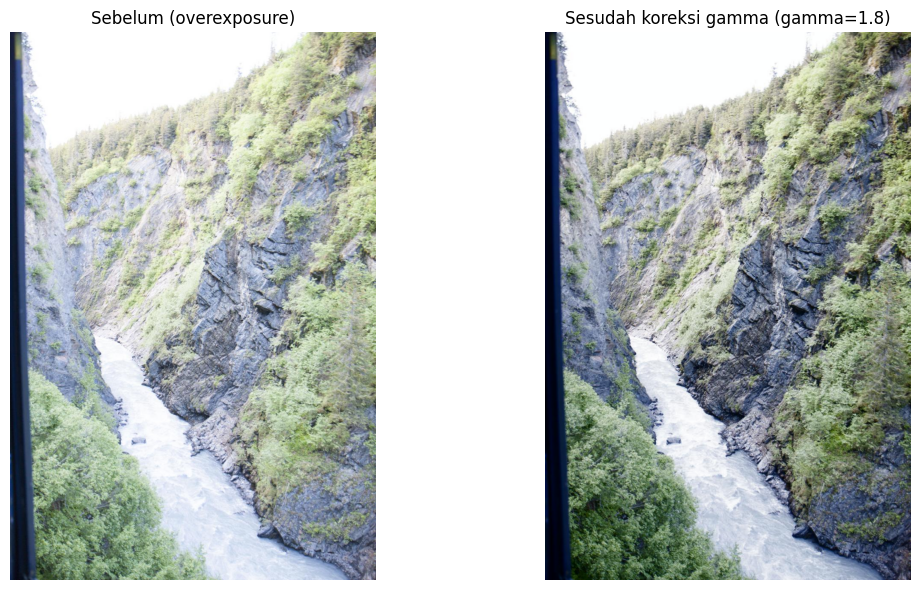

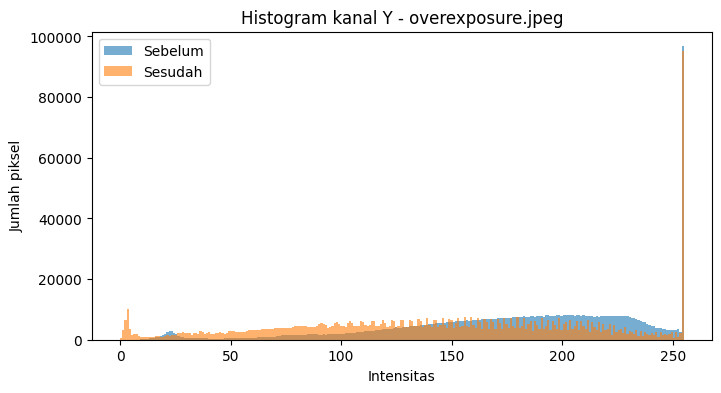

In [ ]:
overexposure_result = gamma_correction_luminance(overexposure, gamma=1.8)
show_comparison(overexposure, overexposure_result, "Sebelum (overexposure)", "Sesudah koreksi gamma (gamma=1.8)")
show_histogram(overexposure, overexposure_result, "Histogram kanal Y - overexposure.jpeg")

##Enhancement citra blur (blur.jpeg)

Citra bianglala ini mengalami blur akibat fokus kamera yang tidak tepat. Unsharp masking diterapkan dengan mengurangkan versi Gaussian blur dari citra asli untuk mendapatkan komponen detail, kemudian komponen tersebut dikuatkan dan ditambahkan kembali ke citra asli.

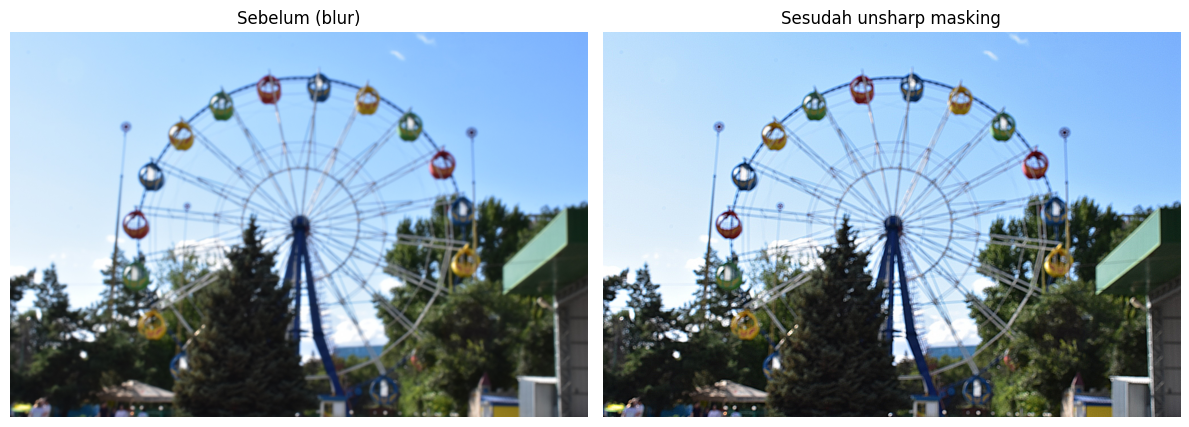

In [ ]:
blur_result = unsharp_mask(blur, kernel_size=9, sigma=3.0, alpha=2.5)
show_comparison(blur, blur_result, "Sebelum (blur)", "Sesudah unsharp masking")

##Menyimpan seluruh hasil enhancement

Seluruh hasil enhancement disimpan ke folder output dalam format PNG agar dapat dilampirkan pada laporan.

In [ ]:
os.makedirs("output", exist_ok=True)
save_image(low_contrast_result, "output/low_contrast_result.png")
save_image(underexposure_result, "output/underexposure_result.png")
save_image(overexposure_result, "output/overexposure_result.png")
save_image(blur_result, "output/blur_result.png")